# Batch Ranking and Exogenous Workbench (N5)

This notebook demonstrates two deterministic workflows:

1. Batch triage ranking across multiple signals.
2. Exogenous driver screening with redundancy penalty and optional BH FDR interpretation.

The notebook reuses library use cases and result models from `src/forecastability`.

In [ ]:
%matplotlib inline
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from forecastability.config import ExogenousScreeningWorkbenchConfig
from forecastability.datasets import (
    generate_ar1,
    generate_henon_map,
    generate_sine_wave,
    generate_white_noise,
)
from forecastability.triage.batch_models import BatchSeriesRequest, BatchTriageRequest
from forecastability.use_cases.run_batch_triage import run_batch_triage
from forecastability.types import ExogenousBenchmarkResult
from forecastability.use_cases.run_exogenous_screening_workbench import (
    run_exogenous_screening_workbench,
)

os.environ.setdefault("MPLBACKEND", "inline")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("Environment ready")

Environment ready


## Part A: Batch Ranking (F7)

Signals span low-to-high forecastability structure; batch triage returns deterministic ranks and diagnostic columns.

In [2]:
n = 280
series_specs: list[tuple[str, np.ndarray]] = [
    ("white_noise", generate_white_noise(n_samples=n, random_state=42)),
    ("ar1_phi_0_85", generate_ar1(n_samples=n, phi=0.85, random_state=0)),
    ("sine_wave", generate_sine_wave(n_samples=n, cycles=9.0, noise_std=0.08, random_state=7)),
    ("henon", generate_henon_map(n_samples=n, discard=100)),
]

batch_request = BatchTriageRequest(
    items=[
        BatchSeriesRequest(series_id=name, series=series.tolist()) for name, series in series_specs
    ],
    max_lag=14,
    n_surrogates=99,
    random_state=42,
)

batch_response = run_batch_triage(batch_request)
batch_df = pd.DataFrame(
    [row.model_dump(mode="json") for row in batch_response.summary_table]
).sort_values("rank")
batch_df

,rank,series_id,outcome,readiness_status,warning_codes,forecastability_profile,forecastability_class,directness_class,directness_ratio,exogenous_usefulness,recommended_next_action,recommendation,error_code,error_message,spectral_predictability,permutation_entropy,complexity_band_label
0,1,henon,ok,clear,,high:high:rich_models_with_structured_memory,high,high,0.729286,not_applicable,prioritize_structured_models,"HIGH -> Complex structured models (deep AR, no...",None,None,0.177114,0.673389,high
1,2,ar1_phi_0_85,ok,clear,,high:medium:compact_structured_models,high,medium,0.244210,not_applicable,prioritize_structured_models,"HIGH -> Complex structured models (deep AR, no...",None,None,0.319925,0.936823,high
2,3,sine_wave,ok,clear,,high:low:compact_structured_models,high,low,0.115131,not_applicable,prioritize_structured_models,"HIGH -> Complex structured models (deep AR, no...",None,None,0.802495,0.682997,medium
3,4,white_noise,ok,clear,,medium:high:nonlinear_direct_models,medium,high,0.554580,not_applicable,validate_compact_models,MEDIUM -> Seasonal ARIMA / LightGBM,None,None,0.092157,0.991561,high


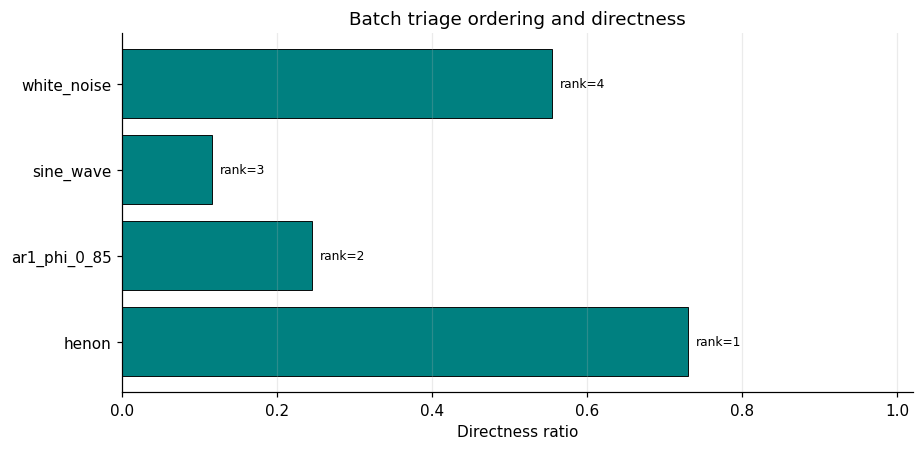

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
plot_df = batch_df.copy()
plot_df["directness_ratio"] = pd.to_numeric(plot_df["directness_ratio"], errors="coerce")
ax.barh(
    plot_df["series_id"],
    plot_df["directness_ratio"],
    color="teal",
    edgecolor="black",
    linewidth=0.6,
)
for _, row in plot_df.iterrows():
    ax.text(
        float(row["directness_ratio"]) + 0.01,
        row["series_id"],
        f"rank={int(row['rank'])}",
        va="center",
        fontsize=8,
    )
ax.set_xlim(0.0, 1.02)
ax.set_xlabel("Directness ratio")
ax.set_title("Batch triage ordering and directness")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## Part B: Exogenous Screening Workbench (F8)

To keep this walkthrough deterministic and fast, we use a stub pair evaluator with fixed horizon profiles and run the official workbench use case.

The enhanced configuration enables:
- profile-shape redundancy penalty (`redundancy_alpha > 0`),
- BH FDR correction (`apply_bh_correction=True`).

In [4]:
horizons = list(range(1, 13))
driver_profiles: dict[str, dict[int, tuple[float, float, float]]] = {
    "industrial_production": {
        h: (0.26 - 0.018 * (h - 1), 0.20 - 0.015 * (h - 1), 0.76) for h in horizons
    },
    "credit_spread": {h: (0.25 - 0.018 * (h - 1), 0.19 - 0.015 * (h - 1), 0.75) for h in horizons},
    "consumer_confidence": {
        h: (
            0.08 + 0.015 * np.exp(-((h - 6.0) ** 2) / 8.0),
            0.06 + 0.013 * np.exp(-((h - 6.0) ** 2) / 8.0),
            0.80,
        )
        for h in horizons
    },
    "oil_price": {h: (0.11, 0.075, 0.68) for h in horizons},
    "noise_series": {h: (0.012, 0.010, 0.90) for h in horizons},
}

for h in horizons:
    raw, conditioned, _ = driver_profiles["noise_series"][h]
    if h % 3 == 0:
        driver_profiles["noise_series"][h] = (raw, conditioned * 1.5, 1.20)


def stub_pair_evaluator(
    target: np.ndarray,
    exog: np.ndarray,
    *,
    case_id: str,
    target_name: str,
    exog_name: str,
    horizons: list[int],
    n_origins: int,
    random_state: int,
    n_surrogates: int,
    min_pairs_raw: int,
    min_pairs_partial: int,
    analysis_scope: str,
    project_extension: bool,
) -> ExogenousBenchmarkResult:
    del target, exog, n_origins, random_state, n_surrogates
    del min_pairs_raw, min_pairs_partial, analysis_scope, project_extension

    spec = driver_profiles[exog_name]
    warning_horizons = [h for h in horizons if spec[h][2] > 1.0]
    return ExogenousBenchmarkResult(
        case_id=case_id,
        target_name=target_name,
        exog_name=exog_name,
        horizons=horizons,
        raw_cross_mi_by_horizon={h: float(spec[h][0]) for h in horizons},
        conditioned_cross_mi_by_horizon={h: float(spec[h][1]) for h in horizons},
        directness_ratio_by_horizon={h: float(spec[h][2]) for h in horizons},
        origins_used_by_horizon={h: 6 for h in horizons},
        warning_horizons=warning_horizons,
        metadata={"stub": 1},
    )


target = generate_ar1(n_samples=240, phi=0.75, random_state=101)
drivers = {
    name: generate_white_noise(n_samples=240, random_state=400 + idx)
    for idx, name in enumerate(driver_profiles)
}

baseline_cfg = ExogenousScreeningWorkbenchConfig.model_validate(
    {
        "horizons": horizons,
        "n_origins": 6,
        "random_state": 42,
        "n_surrogates": 99,
        "min_pairs_raw": 10,
        "min_pairs_partial": 10,
        "redundancy_alpha": 0.0,
        "apply_bh_correction": False,
    }
)
enhanced_cfg = ExogenousScreeningWorkbenchConfig.model_validate(
    {
        "horizons": horizons,
        "n_origins": 6,
        "random_state": 42,
        "n_surrogates": 99,
        "min_pairs_raw": 10,
        "min_pairs_partial": 10,
        "redundancy_alpha": 0.5,
        "apply_bh_correction": True,
        "bh_fdr_alpha": 0.10,
    }
)

baseline_result = run_exogenous_screening_workbench(
    target,
    drivers,
    target_name="macro_target",
    config=baseline_cfg,
    pair_evaluator=stub_pair_evaluator,
)
enhanced_result = run_exogenous_screening_workbench(
    target,
    drivers,
    target_name="macro_target",
    config=enhanced_cfg,
    pair_evaluator=stub_pair_evaluator,
)

In [5]:
base_df = pd.DataFrame(
    [row.model_dump(mode="json") for row in baseline_result.driver_summaries]
).sort_values("overall_rank")
enh_df = pd.DataFrame(
    [row.model_dump(mode="json") for row in enhanced_result.driver_summaries]
).sort_values("overall_rank")

comparison_df = base_df[["driver_name", "overall_rank", "mean_usefulness_score"]].merge(
    enh_df[
        [
            "driver_name",
            "overall_rank",
            "mean_usefulness_score",
            "bh_significant",
            "redundancy_score",
            "recommendation",
        ]
    ],
    on="driver_name",
    suffixes=("_baseline", "_enhanced"),
)
comparison_df.sort_values("overall_rank_enhanced")

,driver_name,overall_rank_baseline,mean_usefulness_score_baseline,overall_rank_enhanced,mean_usefulness_score_enhanced,bh_significant,redundancy_score,recommendation
0,industrial_production,1,0.089300,1,0.089300,True,NaN,keep
1,credit_spread,2,0.080625,2,0.080625,True,0.999429,keep
2,consumer_confidence,3,0.052331,3,0.052331,True,0.917580,review
3,oil_price,4,0.051000,4,0.051000,True,0.997600,review
4,noise_series,5,0.011000,5,0.011000,True,0.968496,reject


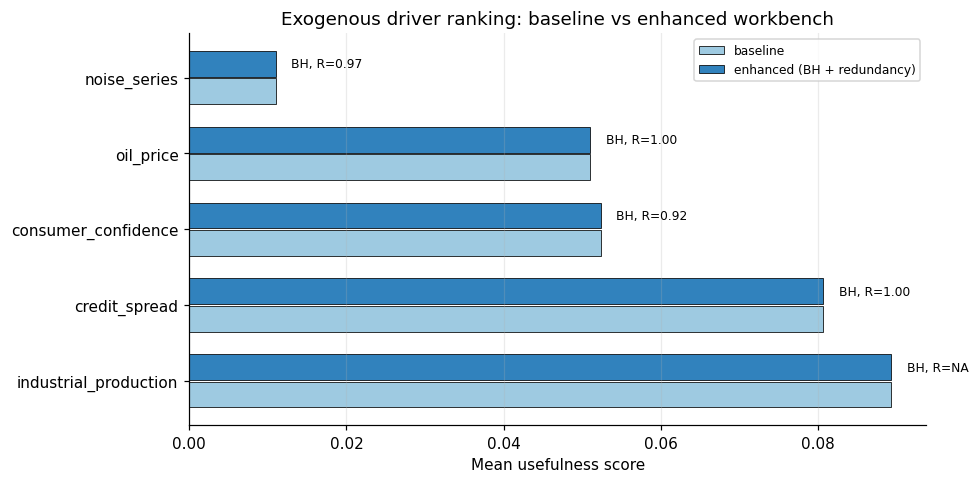

In [6]:
fig, ax = plt.subplots(figsize=(9.0, 4.5))
plot_df = comparison_df.sort_values("overall_rank_enhanced")
y = np.arange(plot_df.shape[0])

ax.barh(
    y - 0.18,
    plot_df["mean_usefulness_score_baseline"],
    height=0.34,
    label="baseline",
    color="#9ecae1",
    edgecolor="black",
    linewidth=0.5,
)
ax.barh(
    y + 0.18,
    plot_df["mean_usefulness_score_enhanced"],
    height=0.34,
    label="enhanced (BH + redundancy)",
    color="#3182bd",
    edgecolor="black",
    linewidth=0.5,
)

for idx, row in plot_df.reset_index(drop=True).iterrows():
    bh_flag = "BH" if bool(row["bh_significant"]) else "no-BH"
    red = row["redundancy_score"]
    red_text = f"R={red:.2f}" if pd.notna(red) else "R=NA"
    ax.text(
        float(row["mean_usefulness_score_enhanced"]) + 0.002,
        idx + 0.18,
        f"{bh_flag}, {red_text}",
        va="center",
        fontsize=8,
    )

ax.set_yticks(y)
ax.set_yticklabels(plot_df["driver_name"])
ax.set_xlabel("Mean usefulness score")
ax.set_title("Exogenous driver ranking: baseline vs enhanced workbench")
ax.grid(axis="x", alpha=0.25)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

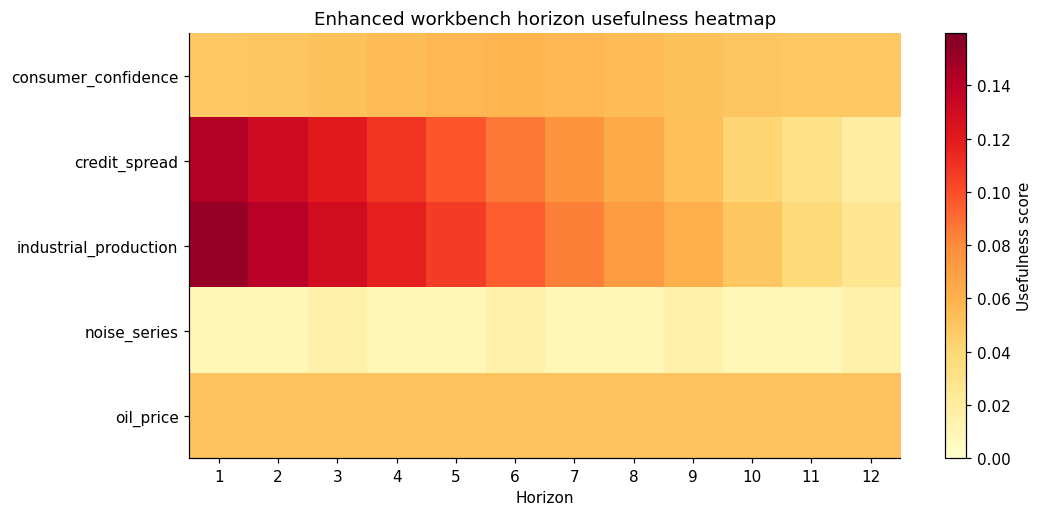

In [7]:
horizon_rows = pd.DataFrame(
    [row.model_dump(mode="json") for row in enhanced_result.horizon_usefulness_rows]
)
pivot = horizon_rows.pivot(
    index="driver_name", columns="horizon", values="usefulness_score"
).sort_index()

fig, ax = plt.subplots(figsize=(10, 4.8))
im = ax.imshow(
    pivot.values, aspect="auto", cmap="YlOrRd", vmin=0.0, vmax=float(np.max(pivot.values) * 1.05)
)
ax.set_xticks(np.arange(pivot.shape[1]))
ax.set_xticklabels([str(h) for h in pivot.columns])
ax.set_yticks(np.arange(pivot.shape[0]))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Horizon")
ax.set_title("Enhanced workbench horizon usefulness heatmap")
plt.colorbar(im, ax=ax, label="Usefulness score")
plt.tight_layout()
plt.show()

## Interpretation Notes

- Batch ranking combines readiness, forecastability profile, directness, and next-action fields into deterministic ordering.
- Enhanced exogenous screening keeps the same core usefulness definition but can down-weight redundant profiles and filter weak evidence with BH correction.
- `bh_significant` indicates whether a driver remains significant after FDR control; `redundancy_score` highlights overlap with already selected profiles.